***Data Collection and Database Setup***

In [2]:
import pandas as pd

In [3]:
trxn= pd.read_csv('Retail_Data_Transactions.csv') #importing dataset
trxn

,customer_id,trans_date,tran_amount
0,CS5295,11-Feb-13,35
1,CS4768,15-Mar-15,39
2,CS2122,26-Feb-13,52
3,CS1217,16-Nov-11,99
4,CS1850,20-Nov-13,78
...,...,...,...
124995,CS8433,26-Jun-11,64
124996,CS7232,19-Aug-14,38
124997,CS8731,28-Nov-14,42
124998,CS8133,14-Dec-13,13


In [4]:
response= pd.read_csv('Retail_Data_Response.csv')
response

,customer_id,response
0,CS1112,0
1,CS1113,0
2,CS1114,1
3,CS1115,1
4,CS1116,1
...,...,...
6879,CS8996,0
6880,CS8997,0
6881,CS8998,0
6882,CS8999,0


**Data Cleaning and Preparation**

In [6]:
df= trxn.merge(response, on='customer_id', how='left')
df

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


In [7]:
# CHECK MISSING VALUES
df.isnull().sum()

customer_id     0
trans_date      0
tran_amount     0
response       31
dtype: int64

In [8]:
df=df.dropna()
df

,customer_id,trans_date,tran_amount,response
0,CS5295,11-Feb-13,35,1.0
1,CS4768,15-Mar-15,39,1.0
2,CS2122,26-Feb-13,52,0.0
3,CS1217,16-Nov-11,99,0.0
4,CS1850,20-Nov-13,78,0.0
...,...,...,...,...
124995,CS8433,26-Jun-11,64,0.0
124996,CS7232,19-Aug-14,38,0.0
124997,CS8731,28-Nov-14,42,0.0
124998,CS8133,14-Dec-13,13,0.0


In [9]:
#changing dtypes
df['trans_date']= pd.to_datetime(df['trans_date'])
df['response'] = df['response'].astype('int64')
df

C:\Users\komal\AppData\Local\Temp\ipykernel_9984\2658238007.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['trans_date']= pd.to_datetime(df['trans_date'])
C:\Users\komal\AppData\Local\Temp\ipykernel_9984\2658238007.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['trans_date']= pd.to_datetime(df['trans_date'])
C:\Users\komal\AppData\Local\Temp\ipykernel_9984\2658238007.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs

,customer_id,trans_date,tran_amount,response
0,CS5295,2013-02-11,35,1
1,CS4768,2015-03-15,39,1
2,CS2122,2013-02-26,52,0
3,CS1217,2011-11-16,99,0
4,CS1850,2013-11-20,78,0
...,...,...,...,...
124995,CS8433,2011-06-26,64,0
124996,CS7232,2014-08-19,38,0
124997,CS8731,2014-11-28,42,0
124998,CS8133,2013-12-14,13,0


In [10]:
set(df['response'])


{0, 1}

In [11]:
df.dtypes

customer_id            object
trans_date     datetime64[ns]
tran_amount             int64
response                int64
dtype: object

In [12]:
#check for outlier #z-score
from scipy import stats
import numpy as np

z_scores= np.abs(stats.zscore(df['tran_amount']))

#set a threshold

threshold= 3
outliers= z_scores>threshold
print(df[outliers])

Empty DataFrame
Columns: [customer_id, trans_date, tran_amount, response]
Index: []


In [13]:
from scipy import stats
import numpy as np


z_scores= np.abs(stats.zscore(df['response']))

threshold= 3
outliers= z_scores>threshold
print(df[outliers])

Empty DataFrame
Columns: [customer_id, trans_date, tran_amount, response]
Index: []


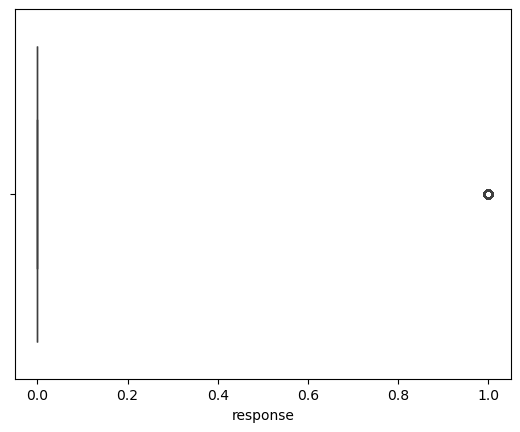

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x= df['response'])
plt.show()

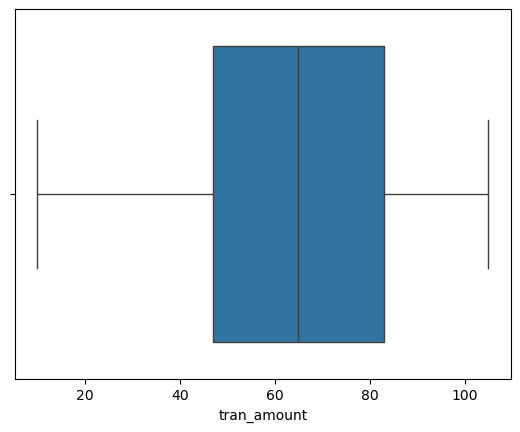

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x= df['tran_amount'])
plt.show()

In [16]:
#creating new column
df['year'] = df['trans_date'].dt.year
df['month'] = df['trans_date'].dt.month
df

C:\Users\komal\AppData\Local\Temp\ipykernel_9984\2573743085.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['year'] = df['trans_date'].dt.year
C:\Users\komal\AppData\Local\Temp\ipykernel_9984\2573743085.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month'] = df['trans_date'].dt.month


,customer_id,trans_date,tran_amount,response,year,month
0,CS5295,2013-02-11,35,1,2013,2
1,CS4768,2015-03-15,39,1,2015,3
2,CS2122,2013-02-26,52,0,2013,2
3,CS1217,2011-11-16,99,0,2011,11
4,CS1850,2013-11-20,78,0,2013,11
...,...,...,...,...,...,...
124995,CS8433,2011-06-26,64,0,2011,6
124996,CS7232,2014-08-19,38,0,2014,8
124997,CS8731,2014-11-28,42,0,2014,11
124998,CS8133,2013-12-14,13,0,2013,12


In [17]:
# Which 3 months have had the highest transaction amounts?

monthly_Sales= df.groupby('month')['tran_amount'].sum()
monthly_Sales= monthly_Sales.sort_values(ascending=False).reset_index().head(3)
monthly_Sales

,month,tran_amount
0,8,726775
1,10,725058
2,1,724089


In [18]:
# Which 3 months have had the smallest transaction amounts?
monthlysales = df.groupby('month')['tran_amount'].sum()
monthlysales = monthlysales.sort_values(ascending=True).reset_index().head(3)
monthlysales

,month,tran_amount
0,4,515746
1,5,633162
2,3,636475


In [19]:
#customer having highest value of order

In [20]:
customer_sales= df.groupby('customer_id')['tran_amount'].sum().reset_index()
customer_sales
top_5_sales = customer_sales.sort_values(by='tran_amount' , ascending = False).head(5)
print(top_5_sales)

     customer_id  tran_amount
3312      CS4424         2933
3208      CS4320         2647
4640      CS5752         2612
3548      CS4660         2527
2687      CS3799         2513


<Axes: xlabel='customer_id', ylabel='tran_amount'>

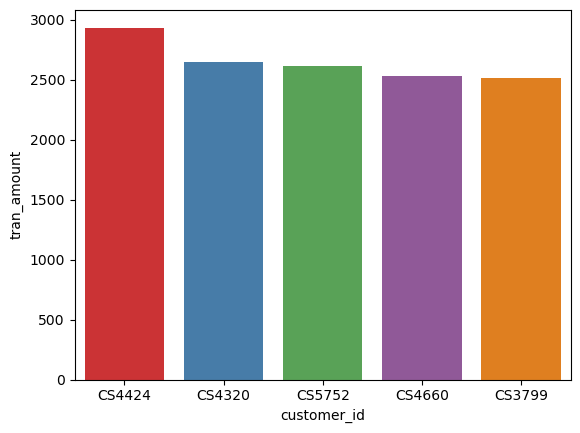

In [21]:
# plotting graph
import seaborn as sns
sns.barplot(x= 'customer_id' , y ='tran_amount' , data = top_5_sales, hue='customer_id', palette='Set1')

In [22]:
# Customers having highest number of orders
customer_counts = df['customer_id'].value_counts().reset_index()
customer_counts
#sort top 5
top_5_customer = customer_counts.sort_values(by = 'count', ascending = False).head(5)
top_5_customer

,customer_id,count
0,CS4424,39
1,CS4320,38
2,CS3799,36
3,CS3013,35
4,CS1215,35


<Axes: xlabel='customer_id', ylabel='count'>

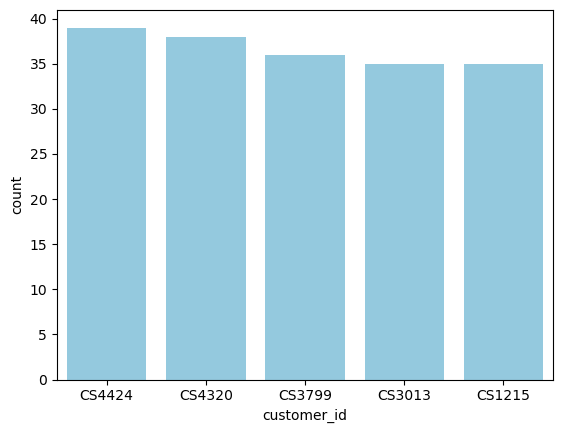

In [23]:
sns.barplot(x = 'customer_id', y = 'count', data = top_5_customer, color= 'skyblue')


**Advanced Analytics #Time series analysis**

In [25]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

df['month_year'] = df['trans_date'].dt.to_period('M')
monthly_sales = df.groupby('month_year')['tran_amount'].sum()
df

C:\Users\komal\AppData\Local\Temp\ipykernel_9984\2598406898.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['month_year'] = df['trans_date'].dt.to_period('M')


,customer_id,trans_date,tran_amount,response,year,month,month_year
0,CS5295,2013-02-11,35,1,2013,2,2013-02
1,CS4768,2015-03-15,39,1,2015,3,2015-03
2,CS2122,2013-02-26,52,0,2013,2,2013-02
3,CS1217,2011-11-16,99,0,2011,11,2011-11
4,CS1850,2013-11-20,78,0,2013,11,2013-11
...,...,...,...,...,...,...,...
124995,CS8433,2011-06-26,64,0,2011,6,2011-06
124996,CS7232,2014-08-19,38,0,2014,8,2014-08
124997,CS8731,2014-11-28,42,0,2014,11,2014-11
124998,CS8133,2013-12-14,13,0,2013,12,2013-12


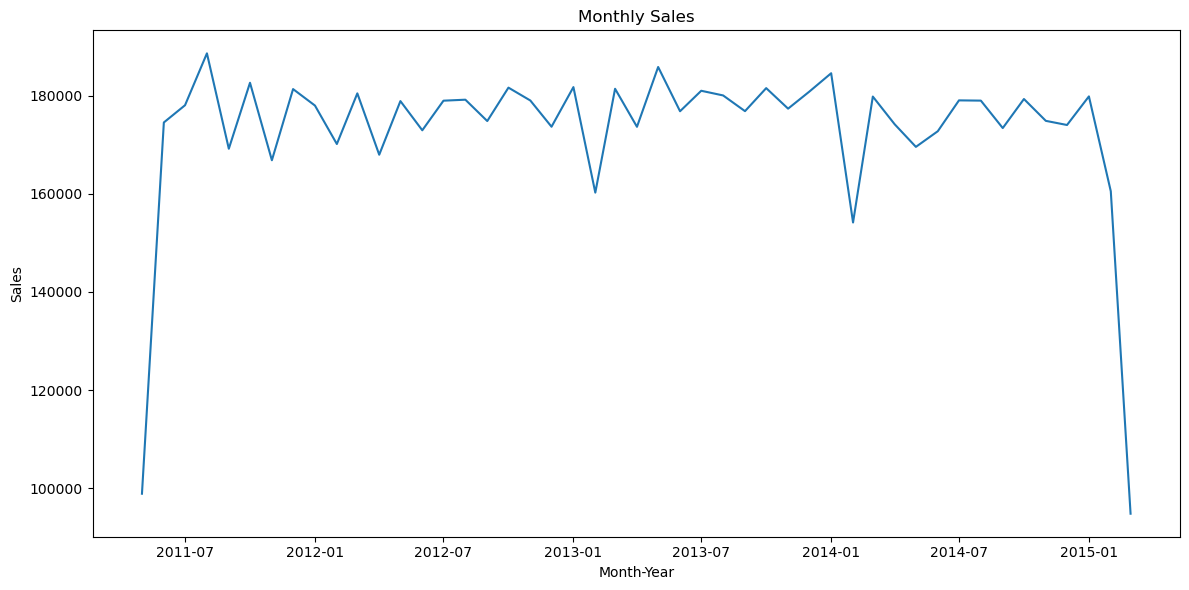

In [26]:
# Convert the PeriodIndex to DateTimeIndex
monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(12,6))  # Increase the size of the figure
plt.plot(monthly_sales.index, monthly_sales.values)  # Plot the data
plt.xlabel('Month-Year')
plt.ylabel('Sales')
plt.title('Monthly Sales')
plt.tight_layout()  # Adjust the layout for better visibility
plt.show()

***Cohort segmentation***
#RFM Analysis

In [28]:
# Recency: Last purchase date
recency = df.groupby('customer_id')['trans_date'].max()

# Frequency: Number of purchases
frequency = df.groupby('customer_id')['trans_date'].count()

# Monetary: Total spend per customer
monetary = df.groupby('customer_id')['tran_amount'].sum()

# Combine all three into a DataFrame
rfm = pd.DataFrame({'recency': recency, 'frequency': frequency, 'monetary': monetary})
rfm


,recency,frequency,monetary
customer_id,,,
CS1112,2015-01-14,15,1012
CS1113,2015-02-09,20,1490
CS1114,2015-02-12,19,1432
CS1115,2015-03-05,22,1659
CS1116,2014-08-25,13,857
...,...,...,...
CS8996,2014-12-09,13,582
CS8997,2014-06-28,14,543
CS8998,2014-12-22,13,624


In [29]:
#Customer Segmentation
def segment_customer(row):
    if row['recency'].year >=2012 and row['frequency']>=15 and row['monetary']>1000:
        return'P0'     #p0 is highest-priority cohort in customer segmentation
    elif 2011 <= row['recency'].year < 2012 and 10 < row['frequency']< 15 and 500 <= row['monetary'] <= 1000:
        return'P1'     #P1 is second- priority customer
    else:
        return 'P2'    #P2 is second- priority customer
rfm['segment'] = rfm.apply(segment_customer, axis=1)
rfm

,recency,frequency,monetary,segment
customer_id,,,,
CS1112,2015-01-14,15,1012,P0
CS1113,2015-02-09,20,1490,P0
CS1114,2015-02-12,19,1432,P0
CS1115,2015-03-05,22,1659,P0
CS1116,2014-08-25,13,857,P2
...,...,...,...,...
CS8996,2014-12-09,13,582,P2
CS8997,2014-06-28,14,543,P2
CS8998,2014-12-22,13,624,P2


**Churn Analysis**

<Axes: xlabel='response'>

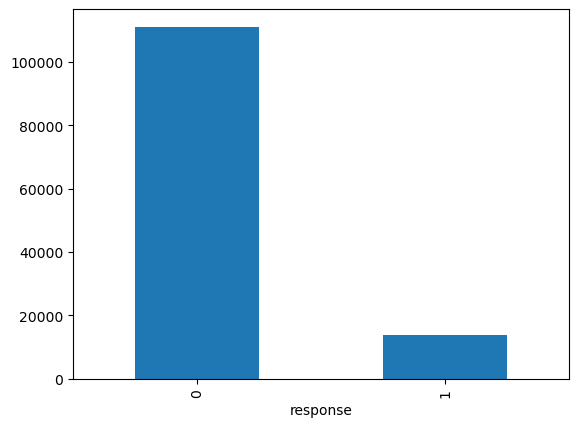

In [75]:
# Count the number of churned(lost customer) and active customers
churn_counts = df['response'].value_counts() #0 means they are not satisfied and 1 means they are satisfied
churn_counts

# Plot
churn_counts.plot(kind='bar')



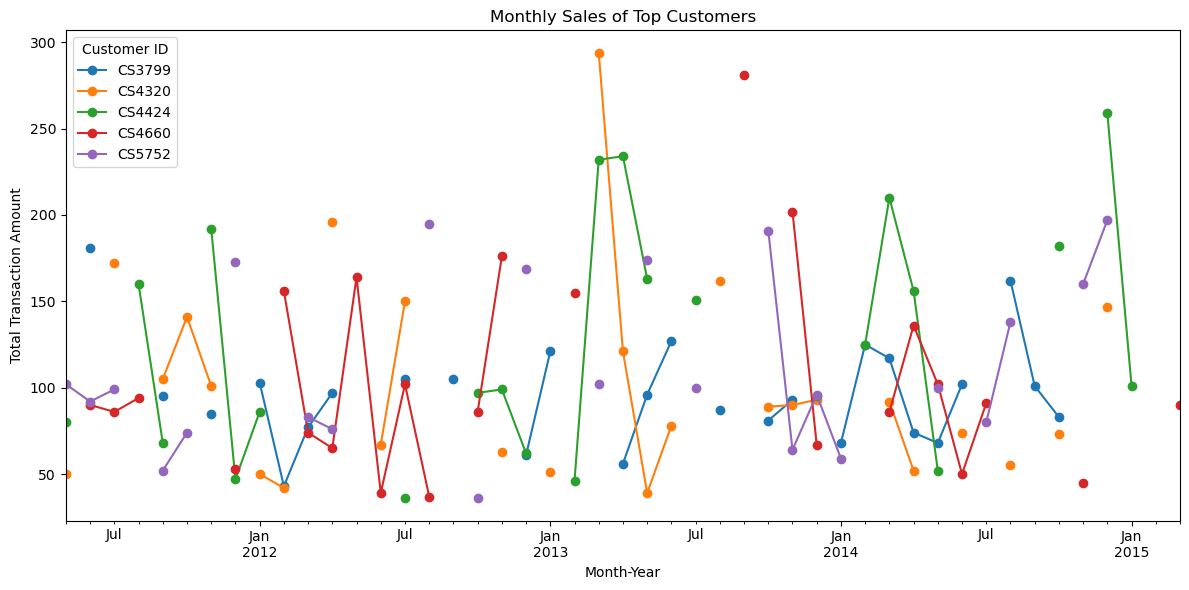

In [67]:
# Top 5 customers
top_5_cus = monetary.sort_values(ascending=False).head(5).index

# Filtering transactions of top 5 customers
top_customers_df = df[df['customer_id'].isin(top_5_cus)]
import matplotlib.pyplot as plt

# Group by customer and month, summing the transaction amount
top_customers_sales = top_customers_df.groupby(['customer_id', 'month_year'])['tran_amount'].sum().unstack(level=0)

# Plot
top_customers_sales.plot(kind='line', figsize=(12, 6), marker='o')

# Enhancing the plot
plt.title('Monthly Sales of Top Customers')
plt.xlabel('Month-Year')
plt.ylabel('Total Transaction Amount')
plt.legend(title='Customer ID', loc='upper left')
plt.tight_layout()
plt.show()




In [33]:
df.to_csv('MainData.csv')


In [34]:
rfm.to_csv('addanalys.csv')

In [ ]:
Conclusion

In this project, I analyzed retail sales data using Python in a Jupyter Notebook environment to understand customer purchasing behavior and sales trends.
Using RFM Analysis, customers were segmented based on their recency, frequency, and monetary value. The analysis identified  high-value customers like CS4424 CS4320, CS3799 etc. who contribute significantly to the overall revenue.
Customer churn analysis revealed that 111127 customers were inactive or at risk of churn, indicating opportunities for improving customer retention strategies.
Additionally, the purchasing patterns of the top 5 customers were analyzed to understand their sales trends over time. Finally, the cleaned dataset and RFM results were exported as CSV files for further analysis and reporting.
Overall, the analysis provides useful insights into customer behavior and sales performance, which can support better business decision-making.
